# PDF dissipated Energy

In [3]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.path.dirname('__file__'), '/home/kduplat/Documents/Data/Pscript2/Fct_scripts')))
from Tools import *

## Pour un système de 128 * 128

### PDF

In [ ]:
""" def process_Eloss_pdf(folder, nmin, nmax, nbins, L1, L2, nu, ndata, minsize): """
def process_Eloss_pdf(folder, L1, L2, ndata, csize = 1e6, nbins = 20):

    histo6_7 = np.zeros(nbins) #Total E lost
    bins6_7 = np.logspace(np.log10(10**-2), np.log10(L1 * L2), nbins + 1)

    nbline = 0
    
    col = [6,7]
    for chunk in chunked_file_reader(f'{folder}/Avalanche_outputB.gz', chunksize=csize, usecols=col):

        histo6_7+=np.histogram(chunk.iloc[:, 0] - chunk.iloc[:, 1], bins = bins6_7)[0]

        nbline += len(chunk)
        if nbline == ndata: break 

    histo6_7 = histo6_7/sum(histo6_7)


    return histo6_7

In [23]:
fnb = np.arange(1,31)
fnb = [1,4,7,9,11,13,15,17,19,21,23,25,27,29]
folderpath = [f'/data1/DATA_Duplat/Brut/E_loss_ava/E_6n{nb}' for nb in fnb]
Tnu = [read_parameters(folder)[2] for folder in folderpath]

Tswitch = np.zeros(len(Tnu))

L1 = 128
L2 = 128
nbins = 20
var = 'nu'
ndata = 1e9
csize = 1e6

results = Parallel(n_jobs=-1)(delayed(process_Eloss_pdf)(folder, L1, L2, ndata, csize, nbins)
                            for (folder) in folderpath)


In [26]:


bins6_7 = np.logspace(np.log10(10**-2), np.log10(L1 * L2), 21)

histo6_7 = np.array(results)

print(np.shape(histo6_7))

(14, 20)


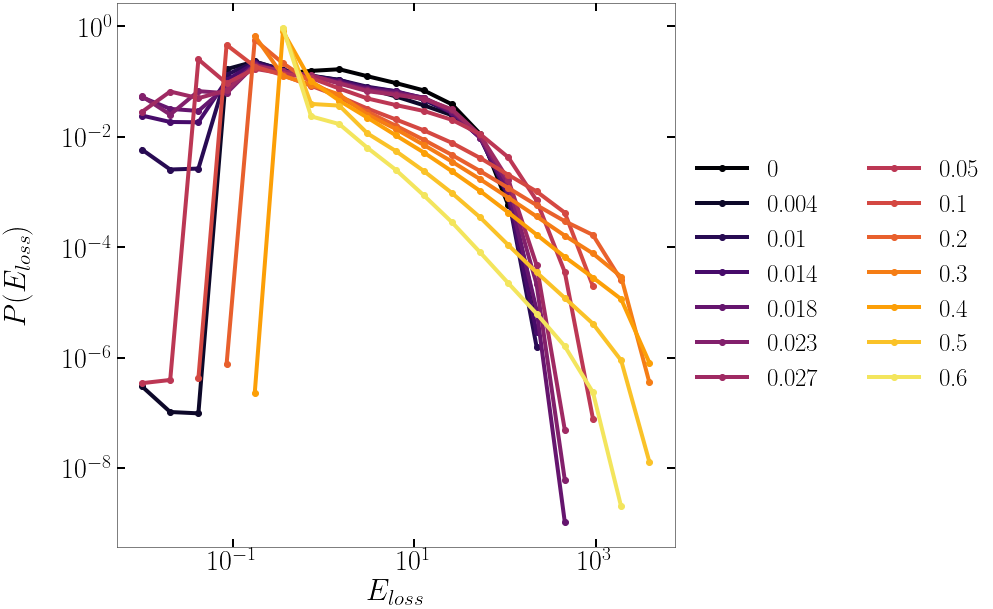

In [27]:
NCURVES = len(histo6_7)
colors = [plt.cm.get_cmap('inferno')(i/NCURVES) for i in range(NCURVES)]

plt.figure(figsize = (10,10))
for j in range(len(folderpath)):

    plt.plot(bins6_7[:-1][histo6_7[j, :]!=0], histo6_7[j][histo6_7[j, :]!=0], color = colors[j], lw = 4, marker = 'o', label = f"{Tnu[j]}")
    """ plt.plot(Tndist11[j, :,0],Tndist11[j, :,1], color = colors[j], linewidth=4, markersize=6, mfc="none", label = f"{Tnu[j]}\nb = {-Tnstat11[j]:.2f}") 
    plt.plot(Tndatafit11[j,:, 0], Tndatafit11[j, :,1], color = 'k', linestyle = '--', linewidth = 3) """
plt.yscale('log')
plt.xlabel(r'$E_{loss}$', fontsize=30)
plt.ylabel(r'$P(E_{loss})$', fontsize=30, labelpad = 30)    
plt.tick_params(labelsize = 28,length = 8, width = 2)
plt.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
plt.yscale('log')
plt.xscale('log')
plt.legend(title_fontsize = 23,ncol = 2,loc='center left', bbox_to_anchor=(1, 0.5),fontsize = 25)
plt.show()

#   Avg Energy

In [9]:
fnb = np.arange(1,15)

Tfolder = ["/data1/DATA_Duplat/Brut/Ava_track/Av5n{}/Snapshots".format(fnb[i]) for i in range(len(fnb))]
Tmean_E = np.zeros(len(Tfolder))
Tmax_E = np.zeros(len(Tfolder))
nbfile = 200

for i, folder in enumerate(Tfolder): 
    list_file = sorted(os.listdir(folder))
    mean_E = 0
    max_E = 0
    for file in list_file[:nbfile]:
        data = 1-np.loadtxt("{}/{}".format(folder, file))
        mean_E += np.mean(data)
        if (np.mean(data)> max_E) : max_E = np.mean(data)
    Tmean_E[i] = mean_E
    Tmax_E[i] = max_E
    
    

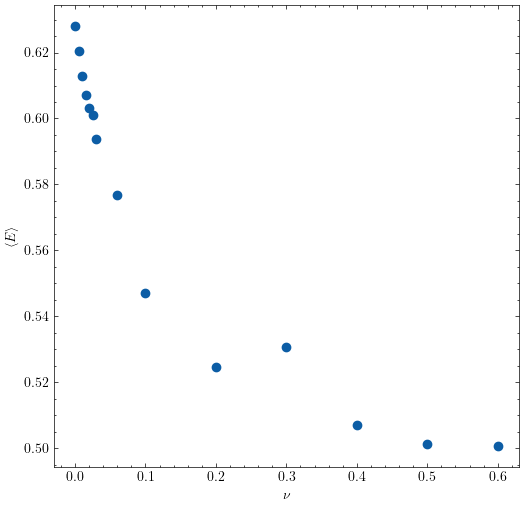

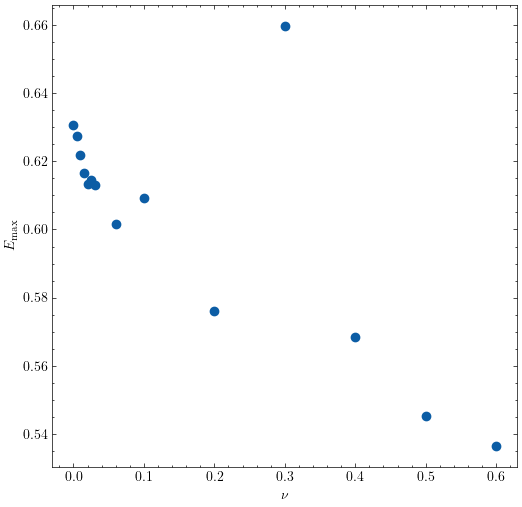

In [12]:

data = np.load("/home/kduplat/Documents/Data/Pscript2/Papier_Memory/Figure2.npz", allow_pickle=True)
Tnu = data["Tvar"]
fig, ax = plt.subplots(figsize = (6,6))
ax.scatter(Tnu, Tmean_E/nbfile)
ax.set_xlabel(r"$\nu$")
ax.set_ylabel(r"$\langle E \rangle$")
plt.show()

fig, ax = plt.subplots(figsize = (6,6))
ax.scatter(Tnu, Tmax_E)
ax.set_xlabel(r"$\nu$")
ax.set_ylabel(r"$E_\mathrm{max}$")
plt.show()